In [ ]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

In [68]:
def get_rotation_matrix(amount: float)->np.ndarray:
    return np.array([
        [math.cos(amount), -math.sin(amount)],
        [math.sin(amount), math.cos(amount)]
    ])

2.011964791627445


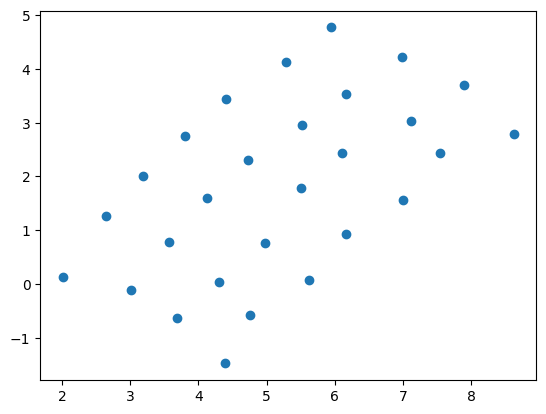

In [69]:
points = []

rows = 4
cols = 7

rotation = math.pi/4
trans_x = 2
trans_y = 1

for i in range(rows * cols):
    r, c = divmod(i, cols)
    off_r = (1/ math.pow((cols/2), 2)) * math.pow(c-(cols/2), 2)*.5
    off_c = (1/ math.pow((rows/2), 2)) * math.pow(r-(rows/2), 2)*.5
    points.append([r + random.gauss()*.1+off_r,c + random.gauss()*.1-off_c])

rotation_matrix = get_rotation_matrix(rotation)

points = np.array(points)
points = points @ rotation_matrix

points = points + np.array([trans_x, trans_y])
print(points[0][0])
plt.scatter(points[:, 0], points[:, 1])


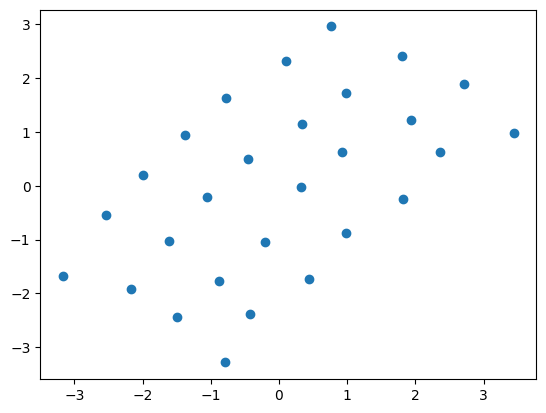

In [70]:
centered = points - np.mean(points, axis=0)
plt.scatter(centered[:,0], centered[:,1])

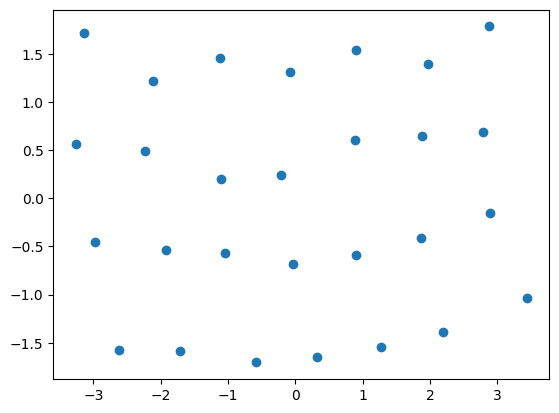

In [71]:
cov = np.cov(centered.T)
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, order]

# Step 4: Rotate points so the first eigenvector aligns with x-axis
rotation_matrix = eigvecs.T  # this rotates the principal component to x-axis
rotated_back = centered @ rotation_matrix.T  # apply rotation

plt.scatter(rotated_back[:,0], rotated_back[:,1])

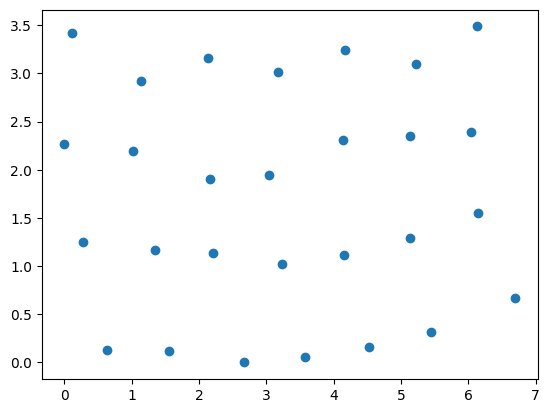

In [72]:
xy_aligned = rotated_back + np.abs(rotated_back.min(axis=0))
plt.scatter(xy_aligned[:,0], xy_aligned[:,1])

In [73]:
optimal_grid = []

for i in range(rows * cols):
    c, r = divmod(i, cols)
    optimal_grid.append([r,c])

optimal_grid = np.array(optimal_grid)

diff = xy_aligned[:, np.newaxis, :] - optimal_grid[np.newaxis, :, :]
cost = np.linalg.norm(diff, axis=-1)
cost

array([[6.72910727, 5.73498376, 4.74333142, 3.75610797, 2.7780391 ,
        1.82391212, 0.96737252, 6.70342997, 5.7048337 , 4.70683351,
        3.70991049, 2.71525138, 1.72677277, 0.76869913, 6.82576458,
        5.8480951 , 4.87948465, 3.92664292, 3.00460959, 2.15333067,
        1.49866178, 7.08845194, 6.1526665 , 5.24065447, 4.36733482,
        3.56128735, 2.87956971, 2.42921302],
       [5.45647666, 4.45858538, 3.46191128, 2.46792945, 1.48206675,
        0.54987994, 0.6389163 , 5.4893402 , 4.49874449, 3.5134809 ,
        2.53976261, 1.59882464, 0.81368686, 0.87631752, 5.70022581,
        4.75377958, 3.83461425, 2.96818337, 2.21719611, 1.73833388,
        1.76851654, 6.07060892, 5.19212275, 4.36623233, 3.62902616,
        3.0455996 , 2.71689585, 2.73630574],
       [4.53425346, 3.53503723, 2.53643886, 1.53966099, 0.55460781,
        0.49459445, 1.47704351, 4.6089583 , 3.6303623 , 2.66768894,
        1.74745477, 0.99530499, 0.96315413, 1.69254239, 4.89137392,
        3.98278453, 3.1304

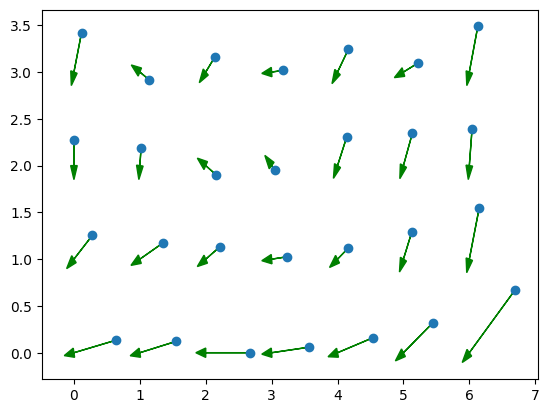

In [74]:
from munkres import Munkres

m = Munkres()
indexes = m.compute(cost)

for to_v, assing_v in indexes:
    plt.arrow(
        xy_aligned[assing_v][0],
        xy_aligned[assing_v][1],
        optimal_grid[to_v][0]-xy_aligned[assing_v][0],
        optimal_grid[to_v][1]-xy_aligned[assing_v][1],
        head_width=.1,
        color='green'
    )
plt.scatter(xy_aligned[:,0], xy_aligned[:,1])
    #plt.plot(
    #    [xy_aligned[assing_v][0], optimal_grid[to_v][0]],
    #    [xy_aligned[assing_v][1], optimal_grid[to_v][1]]
    #)